CELL 1 — Uploading + extracting the zip file


In [3]:
# Colab: upload project_dataset.zip
from google.colab import files
uploaded = files.upload()

import zipfile, os, pandas as pd

# Find the uploaded zip name (in case it differs)
zip_name = [k for k in uploaded.keys() if k.endswith(".zip")][0]
print("Uploaded:", zip_name)

# Extract outer zip
os.makedirs("data_outer", exist_ok=True)
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("data_outer")

print("Outer contents:", os.listdir("data_outer"))

# Extract the nested student.zip
nested_zip_path = "data_outer/student.zip"
os.makedirs("data", exist_ok=True)
with zipfile.ZipFile(nested_zip_path, "r") as z:
    z.extractall("data")

print("Inner contents:", os.listdir("data"))

# Load CSVs (they are ';' separated)
mat_path = "data/student-mat.csv"
por_path = "data/student-por.csv"

df_mat = pd.read_csv(mat_path, sep=";")
df_por = pd.read_csv(por_path, sep=";")

print("Math shape:", df_mat.shape)
print("Por shape:", df_por.shape)
print("Columns:", df_mat.columns.tolist())


Saving project_dataset.zip to project_dataset.zip
Uploaded: project_dataset.zip
Outer contents: ['.student.zip_old', 'student.zip']
Inner contents: ['student-por.csv', 'student-merge.R', 'student-mat.csv', 'student.txt']
Math shape: (395, 33)
Por shape: (649, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


CELL 2 — Define feature groups + preprocessing + models

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ---------------------------
# feature groups
# ---------------------------
FAMILY_FEATURES = [
    "Medu","Fedu","Mjob","Fjob","famsup","famrel","Pstatus","guardian","famsize"
]

SCHOOL_FEATURES = [
    "school","reason","traveltime","studytime","schoolsup","paid","activities","absences","internet"
]

TARGET = "G3"

def make_success_label(df, threshold=10):
    df = df.copy()
    df["success"] = (df[TARGET] >= threshold).astype(int)
    return df

def build_preprocessor(df, selected_features):
    X = df[selected_features].copy()

    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", StandardScaler(), num_cols)
        ],
        remainder="drop"
    )
    return preprocessor

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

# Models
logreg = LogisticRegression(max_iter=5000)
rf = RandomForestClassifier(random_state=42)

#SVM
svm = SVC(probability=False)

# Simple grids (small but valid)
rf_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [None, 5, 10]
}

svm_grid = {
    "clf__C": [0.1, 1, 10],
    "clf__kernel": ["linear", "rbf"]
}


CELL 3 — Run the full “Family vs School vs All” experiment (LogReg + RF + SVM)

In [14]:
def run_experiment(df, dataset_name="dataset", use_svm=False):
    df = make_success_label(df, threshold=10)

    results = []

    for group_name, features in [
        ("FAMILY_ONLY", FAMILY_FEATURES),
        ("SCHOOL_ONLY", SCHOOL_FEATURES),
        ("ALL", sorted(list(set(FAMILY_FEATURES + SCHOOL_FEATURES))))
    ]:
        # Prepare data
        X = df[features]
        y = df["success"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        preprocessor = build_preprocessor(df, features)

        # -----------------
        # Logistic Regression
        # -----------------
        pipe_lr = Pipeline(steps=[
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=5000))
        ])
        pipe_lr.fit(X_train, y_train)
        lr_metrics = evaluate_model(pipe_lr, X_test, y_test)
        results.append({
            "dataset": dataset_name,
            "feature_set": group_name,
            "model": "LogisticRegression",
            **{k: lr_metrics[k] for k in ["accuracy","precision","recall","f1"]},
            "cm": lr_metrics["confusion_matrix"]
        })

        # -----------------
        # Random Forest (with small GridSearch)
        # -----------------
        pipe_rf = Pipeline(steps=[
            ("prep", preprocessor),
            ("clf", RandomForestClassifier(random_state=42))
        ])
        gs_rf = GridSearchCV(pipe_rf, rf_grid, cv=5, scoring="f1", n_jobs=-1)
        gs_rf.fit(X_train, y_train)

        rf_metrics = evaluate_model(gs_rf, X_test, y_test)
        results.append({
            "dataset": dataset_name,
            "feature_set": group_name,
            "model": "RandomForest(GridSearch)",
            **{k: rf_metrics[k] for k in ["accuracy","precision","recall","f1"]},
            "cm": rf_metrics["confusion_matrix"]
        })

        # -----------------
        # SVM (GridSearch)
        # -----------------
        if use_svm:
            pipe_svm = Pipeline(steps=[
                ("prep", preprocessor),
                ("clf", SVC())
            ])
            gs_svm = GridSearchCV(pipe_svm, svm_grid, cv=5, scoring="f1", n_jobs=-1)
            gs_svm.fit(X_train, y_train)

            svm_metrics = evaluate_model(gs_svm, X_test, y_test)
            results.append({
                "dataset": dataset_name,
                "feature_set": group_name,
                "model": "SVM(GridSearch)",
                **{k: svm_metrics[k] for k in ["accuracy","precision","recall","f1"]},
                "cm": svm_metrics["confusion_matrix"]
            })

    return pd.DataFrame(results)

# Run on BOTH datasets
results_mat = run_experiment(df_mat, "student-mat", use_svm=False)
results_por = run_experiment(df_por, "student-por", use_svm=False)

results_all = pd.concat([results_mat, results_por], ignore_index=True)

# Show sorted by best F1
display(results_all.sort_values(["dataset","f1"], ascending=[True, False]))


,dataset,feature_set,model,accuracy,precision,recall,f1,cm
3,student-mat,SCHOOL_ONLY,RandomForest(GridSearch),0.686869,0.684211,0.984848,0.807453,"[[3, 30], [1, 65]]"
1,student-mat,FAMILY_ONLY,RandomForest(GridSearch),0.676768,0.673469,1.000000,0.804878,"[[1, 32], [0, 66]]"
5,student-mat,ALL,RandomForest(GridSearch),0.666667,0.666667,1.000000,0.800000,"[[0, 33], [0, 66]]"
0,student-mat,FAMILY_ONLY,LogisticRegression,0.656566,0.677778,0.924242,0.782051,"[[4, 29], [5, 61]]"
2,student-mat,SCHOOL_ONLY,LogisticRegression,0.626263,0.655914,0.924242,0.767296,"[[1, 32], [5, 61]]"
4,student-mat,ALL,LogisticRegression,0.626263,0.670588,0.863636,0.754967,"[[5, 28], [9, 57]]"
6,student-por,FAMILY_ONLY,LogisticRegression,0.846626,0.846626,1.000000,0.916944,"[[0, 25], [0, 138]]"
7,student-por,FAMILY_ONLY,RandomForest(GridSearch),0.846626,0.846626,1.000000,0.916944,"[[0, 25], [0, 138]]"
11,student-por,ALL,RandomForest(GridSearch),0.846626,0.846626,1.000000,0.916944,"[[0, 25], [0, 138]]"
9,student-por,SCHOOL_ONLY,RandomForest(GridSearch),0.840491,0.845679,0.992754,0.913333,"[[0, 25], [1, 137]]"


CELL 4 — Confusion matrices (pretty print)

In [15]:
def print_confusions(df_results):
    for i, row in df_results.iterrows():
        print("="*70)
        print(row["dataset"], "|", row["feature_set"], "|", row["model"])
        print(f"Acc={row['accuracy']:.3f}  Prec={row['precision']:.3f}  Rec={row['recall']:.3f}  F1={row['f1']:.3f}")
        print("Confusion Matrix [ [TN FP] [FN TP] ]:")
        print(row["cm"])

print_confusions(results_all.sort_values(["dataset","f1"], ascending=[True, False]).head(6))
#The confusion matrices were printed only for the student-mat dataset to avoid redundancy, while overall performance metrics for both datasets were summarized in the results table.


student-mat | SCHOOL_ONLY | RandomForest(GridSearch)
Acc=0.687  Prec=0.684  Rec=0.985  F1=0.807
Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 3 30]
 [ 1 65]]
student-mat | FAMILY_ONLY | RandomForest(GridSearch)
Acc=0.677  Prec=0.673  Rec=1.000  F1=0.805
Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 1 32]
 [ 0 66]]
student-mat | ALL | RandomForest(GridSearch)
Acc=0.667  Prec=0.667  Rec=1.000  F1=0.800
Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 0 33]
 [ 0 66]]
student-mat | FAMILY_ONLY | LogisticRegression
Acc=0.657  Prec=0.678  Rec=0.924  F1=0.782
Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 4 29]
 [ 5 61]]
student-mat | SCHOOL_ONLY | LogisticRegression
Acc=0.626  Prec=0.656  Rec=0.924  F1=0.767
Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 1 32]
 [ 5 61]]
student-mat | ALL | LogisticRegression
Acc=0.626  Prec=0.671  Rec=0.864  F1=0.755
Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 5 28]
 [ 9 57]]


CELL 5 — Feature importance (Random Forest) + Logistic coefficients (interpretable)

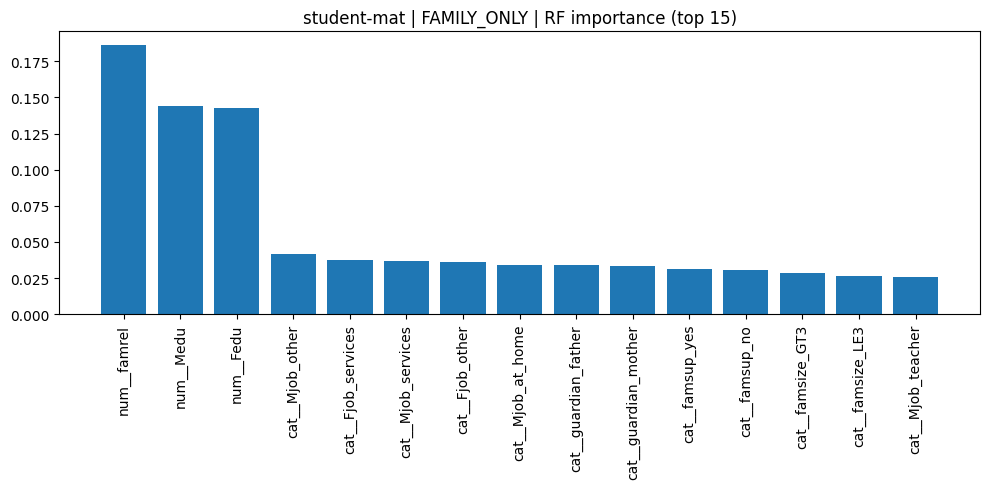

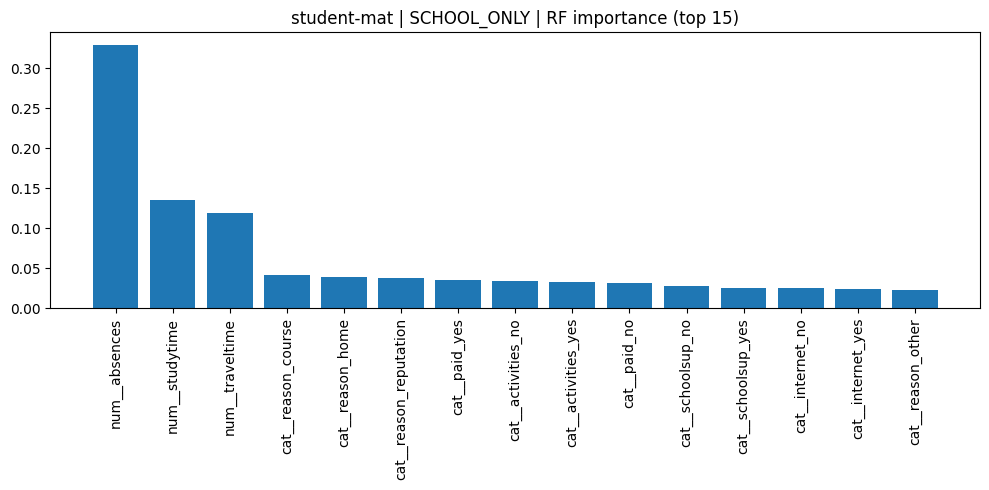

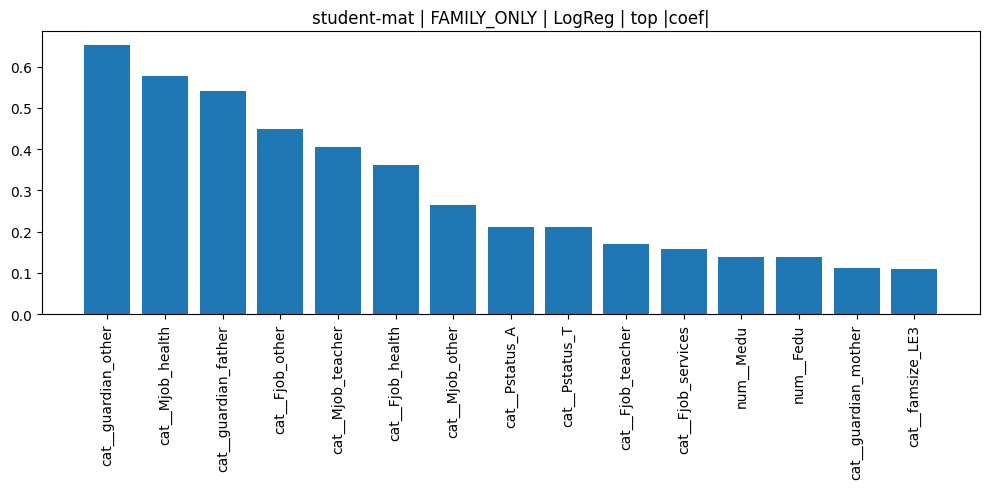

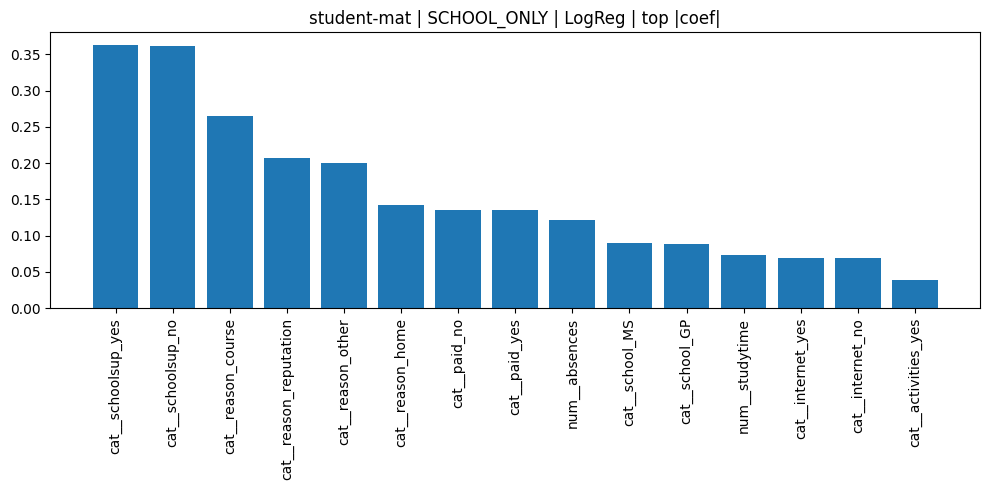

In [16]:
import matplotlib.pyplot as plt

def get_feature_names(preprocessor, input_features):
    # Works for sklearn >= 1.0
    return preprocessor.get_feature_names_out(input_features)

def plot_rf_importance(df, features, title="RF Feature Importance"):
    df = make_success_label(df)
    X = df[features]
    y = df["success"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    preprocessor = build_preprocessor(df, features)

    pipe_rf = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=500, random_state=42))
    ])
    pipe_rf.fit(X_train, y_train)

    # importance on transformed feature space
    feat_names = get_feature_names(pipe_rf.named_steps["prep"], X_train.columns)
    importances = pipe_rf.named_steps["clf"].feature_importances_

    imp = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(10,5))
    plt.bar(imp["feature"], imp["importance"])
    plt.xticks(rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_logreg_coeffs(df, features, title="LogReg Coefficients (|coef|)"):
    df = make_success_label(df)
    X = df[features]
    y = df["success"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    preprocessor = build_preprocessor(df, features)

    pipe_lr = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=5000))
    ])
    pipe_lr.fit(X_train, y_train)

    feat_names = get_feature_names(pipe_lr.named_steps["prep"], X_train.columns)
    coefs = pipe_lr.named_steps["clf"].coef_[0]

    coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})
    coef_df["abscoef"] = coef_df["coef"].abs()
    top = coef_df.sort_values("abscoef", ascending=False).head(15)

    plt.figure(figsize=(10,5))
    plt.bar(top["feature"], top["abscoef"])
    plt.xticks(rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Example: student-mat, school-only vs family-only
plot_rf_importance(df_mat, FAMILY_FEATURES, "student-mat | FAMILY_ONLY | RF importance (top 15)")
plot_rf_importance(df_mat, SCHOOL_FEATURES, "student-mat | SCHOOL_ONLY | RF importance (top 15)")

plot_logreg_coeffs(df_mat, FAMILY_FEATURES, "student-mat | FAMILY_ONLY | LogReg | top |coef|")
plot_logreg_coeffs(df_mat, SCHOOL_FEATURES, "student-mat | SCHOOL_ONLY | LogReg | top |coef|")

# Feature importance plots are presented only for student-mat to keep the analysis concise.
# The main performance comparison for both student-mat and student-por is provided in the results table (cell3).



CELL 6 — PCA plots (Family vs School) colored by success/fail

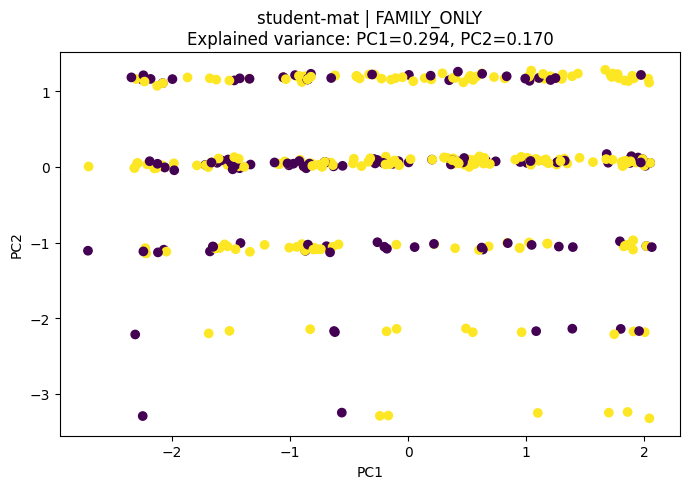

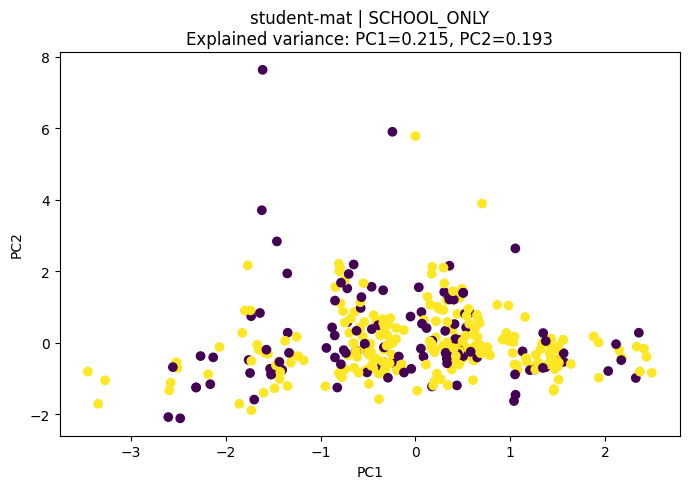

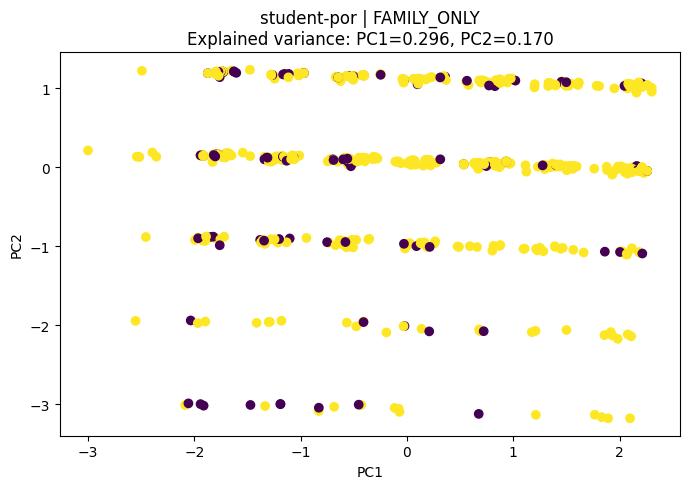

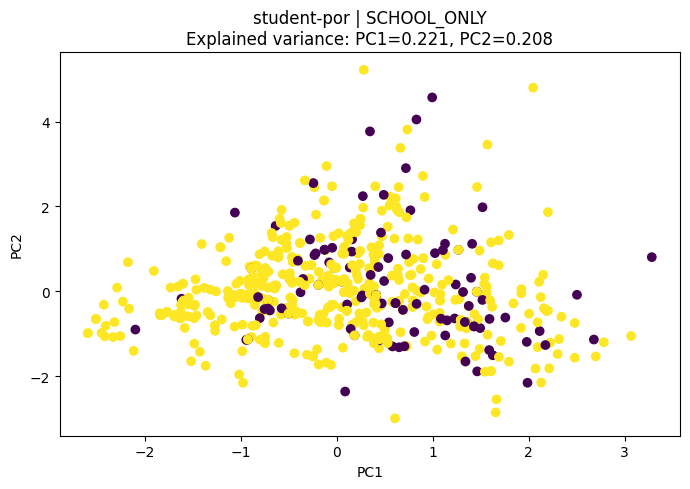

In [12]:
from sklearn.decomposition import PCA

def pca_plot(df, features, title="PCA Plot"):
    df = make_success_label(df)
    X = df[features]
    y = df["success"].values

    preprocessor = build_preprocessor(df, features)
    X_trans = preprocessor.fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_trans.toarray() if hasattr(X_trans, "toarray") else X_trans)

    var = pca.explained_variance_ratio_
    plt.figure(figsize=(7,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
    plt.title(f"{title}\nExplained variance: PC1={var[0]:.3f}, PC2={var[1]:.3f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

pca_plot(df_mat, FAMILY_FEATURES, "student-mat | FAMILY_ONLY")
pca_plot(df_mat, SCHOOL_FEATURES, "student-mat | SCHOOL_ONLY")

pca_plot(df_por, FAMILY_FEATURES, "student-por | FAMILY_ONLY")
pca_plot(df_por, SCHOOL_FEATURES, "student-por | SCHOOL_ONLY")
